# 🛒 E-Commerce Sales Analysis

## 📊 Project Overview

This project analyzes an e-commerce sales dataset using Python and Pandas.

The analysis focuses on sales, profit, quantity sold, categories, cities, states, sub-categories, payment modes, and monthly sales trends.

## 🛠️ Tools & Technologies

- Python
- Pandas
- Matplotlib
- Google Colab

## 🎯 Objectives

- Analyze overall sales and profit
- Identify top-performing categories and cities
- Analyze monthly sales trends
- Compare sales and profit across states
- Analyze sub-category performance
- Understand payment mode distribution
- Generate business-oriented insights

In [47]:
import pandas as pd
import matplotlib.pyplot as plt


In [48]:
orders = pd.read_csv('/content/Orders.csv')
details = pd.read_csv('/content/Details.csv')

print("Orders:")
display(orders.head())

print("Details:")
display(details.head())

Orders:


,Order ID,Order Date,CustomerName,State,City
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura
1,B-25993,03-02-2018,Madhav,Delhi,Delhi
2,B-25973,24-01-2018,Madan Mohan,Uttar Pradesh,Mathura
3,B-25923,27-12-2018,Gopal,Maharashtra,Mumbai
4,B-25757,21-08-2018,Vishakha,Madhya Pradesh,Indore


Details:


,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card


In [49]:
orders["Order Date"] = pd.to_datetime(
    orders["Order Date"],
    format="%d-%m-%Y"
)

df = details.merge(
    orders,
    on="Order ID",
    how="left"
)

df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City
0,B-25681,1096,658,7,Electronics,Electronic Games,COD,2018-06-04,Bhawna,Madhya Pradesh,Indore
1,B-26055,5729,64,14,Furniture,Chairs,EMI,2018-03-10,Harivansh,Uttar Pradesh,Mathura
2,B-25955,2927,146,8,Furniture,Bookcases,EMI,2018-01-16,Shiva,Maharashtra,Pune
3,B-26093,2847,712,8,Electronics,Printers,Credit Card,2018-03-27,Sarita,Maharashtra,Pune
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card,2018-04-01,Vrinda,Maharashtra,Pune


In [12]:
print("Final dataset shape:", df.shape)

Final dataset shape: (1500, 11)


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1500 non-null   object        
 1   Amount        1500 non-null   int64         
 2   Profit        1500 non-null   int64         
 3   Quantity      1500 non-null   int64         
 4   Category      1500 non-null   object        
 5   Sub-Category  1500 non-null   object        
 6   PaymentMode   1500 non-null   object        
 7   Order Date    1500 non-null   datetime64[ns]
 8   CustomerName  1500 non-null   object        
 9   State         1500 non-null   object        
 10  City          1500 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 129.0+ KB


In [54]:
print("Total Sales:", df["Amount"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity Sold:", df["Quantity"].sum())
print("Total Transactions:", len(df))
print("Unique Orders:", df["Order ID"].nunique())


Total Sales: 437771
Total Profit: 36963
Total Quantity Sold: 5615
Total Transactions: 1500
Unique Orders: 500


## 📦 Category Analysis

In [16]:
print("\nSales by Category:")
print(df.groupby("Category")["Amount"].sum().sort_values(ascending=False))

print("\nProfit by Category:")
print(df.groupby("Category")["Profit"].sum().sort_values(ascending=False))


Sales by Category:
Category
Electronics    166267
Clothing       144323
Furniture      127181
Name: Amount, dtype: int64

Profit by Category:
Category
Clothing       13325
Electronics    13162
Furniture      10476
Name: Profit, dtype: int64


In [17]:
category_analysis = df.groupby("Category").agg(
    Sales=("Amount", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

category_analysis["Profit Margin (%)"] = (
    category_analysis["Profit"] / category_analysis["Sales"] * 100
).round(2)

category_analysis.sort_values("Profit Margin (%)", ascending=False)

,Sales,Profit,Quantity,Profit Margin (%)
Category,,,,
Clothing,144323,13325,3516,9.23
Furniture,127181,10476,945,8.24
Electronics,166267,13162,1154,7.92


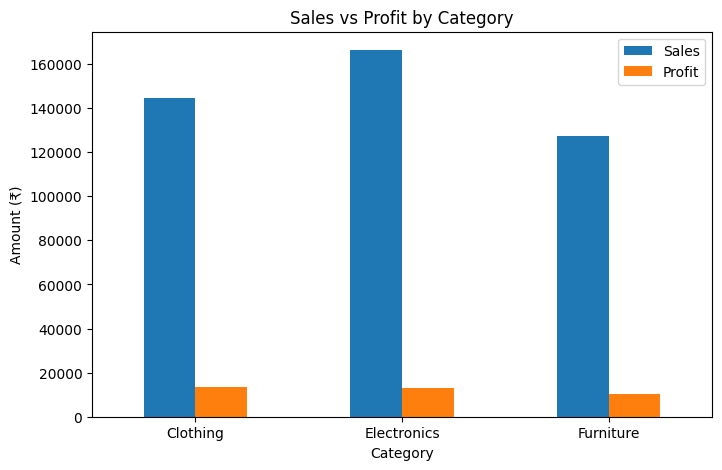

In [20]:
category_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=0)
plt.legend()
plt.show()

## 📅 Monthly Sales Analysis

In [21]:
df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Amount"].sum()

monthly_sales

,Amount
Month,
2018-01,61632
2018-02,38962
2018-03,60694
2018-04,34330
2018-05,29093
2018-06,23658
2018-07,12966
2018-08,31492
2018-09,27283


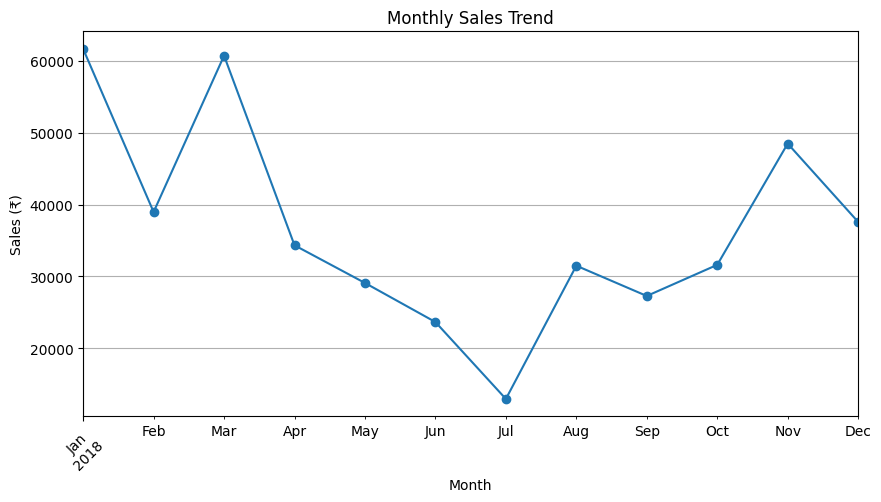

In [22]:
monthly_sales.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 🌎 State Analysis

In [23]:
state_analysis = df.groupby("State").agg(
    Sales=("Amount", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

state_analysis = state_analysis.sort_values(
    "Sales",
    ascending=False
)

state_analysis

,Sales,Profit,Quantity
State,,,
Maharashtra,102498,6963,1091
Madhya Pradesh,87463,7382,1227
Uttar Pradesh,38362,3358,387
Delhi,22957,1958,290
Rajasthan,22334,-323,282
Gujarat,21371,3001,328
Punjab,16786,1571,216
West Bengal,14328,2074,216
Kerala,13871,2435,157


In [24]:
state_analysis.head(10)

,Sales,Profit,Quantity
State,,,
Maharashtra,102498,6963,1091
Madhya Pradesh,87463,7382,1227
Uttar Pradesh,38362,3358,387
Delhi,22957,1958,290
Rajasthan,22334,-323,282
Gujarat,21371,3001,328
Punjab,16786,1571,216
West Bengal,14328,2074,216
Kerala,13871,2435,157


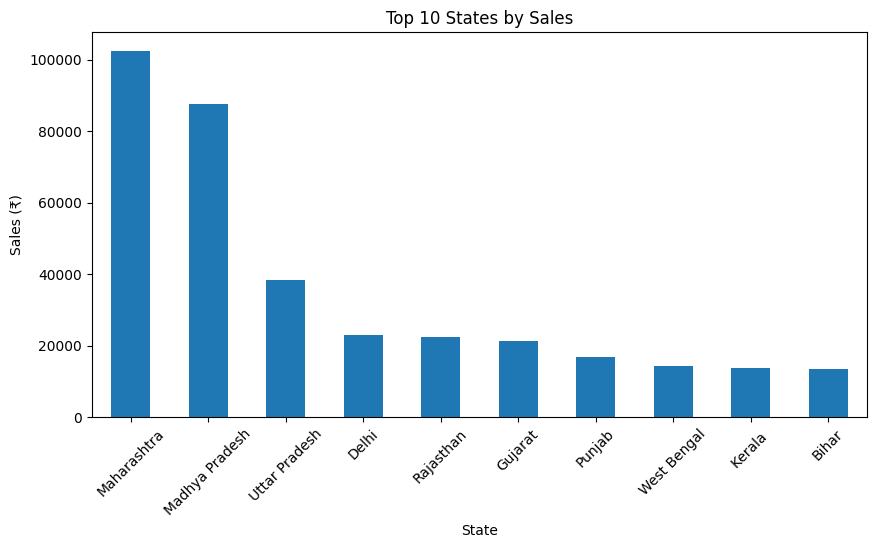

In [25]:
top_states = state_analysis.head(10)

top_states["Sales"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.show()

In [26]:
state_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Sales,Profit,Quantity
State,,,
Madhya Pradesh,87463,7382,1227
Maharashtra,102498,6963,1091
Uttar Pradesh,38362,3358,387
Gujarat,21371,3001,328
Tamil Nadu,6276,2602,91
Kerala,13871,2435,157
West Bengal,14328,2074,216
Delhi,22957,1958,290
Bihar,13417,1787,206


## 🏙️ City Analysis

In [32]:
city_analysis = df.groupby("City").agg(
    Sales=("Amount", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

city_analysis = city_analysis.sort_values(
    "Sales",
    ascending=False
)

city_analysis.head(10)

,Sales,Profit,Quantity
City,,,
Indore,63680,6763,980
Mumbai,58886,803,699
Pune,43612,6160,392
Mathura,28747,3335,194
Bhopal,23783,619,247
Delhi,22957,1958,290
Chandigarh,21142,2778,275
Ahmedabad,14543,1846,235
Kolkata,14328,2074,216


In [33]:
city_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Sales,Profit,Quantity
City,,,
Indore,63680,6763,980
Pune,43612,6160,392
Mathura,28747,3335,194
Chandigarh,21142,2778,275
Chennai,6276,2602,91
Thiruvananthapuram,13871,2435,157
Kolkata,14328,2074,216
Delhi,22957,1958,290
Ahmedabad,14543,1846,235


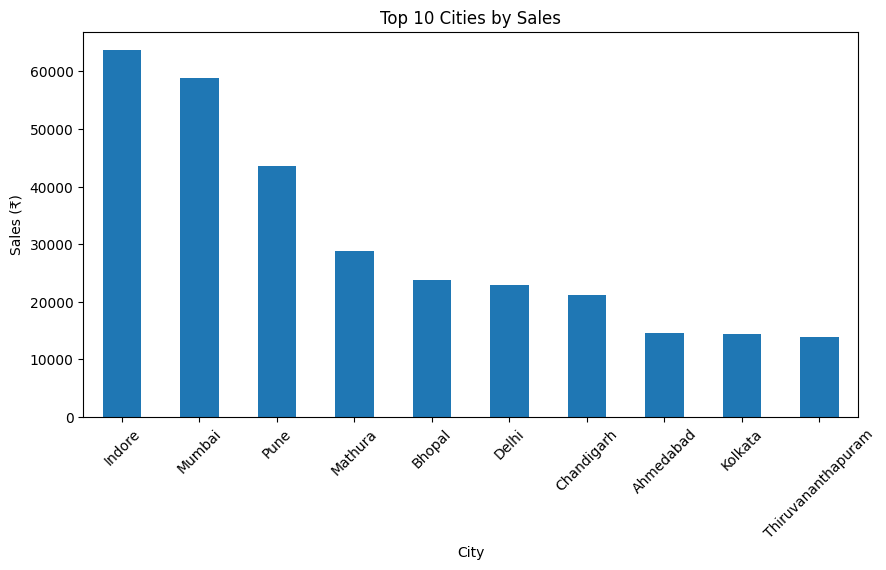

In [34]:
city_sales = city_analysis.head(10)

city_sales["Sales"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.show()

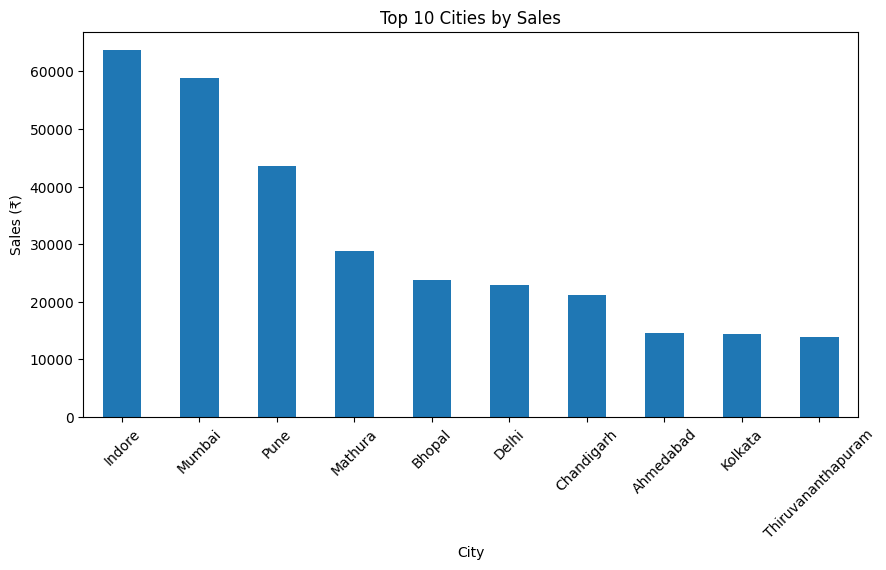

In [35]:
city_sales = city_analysis.head(10)

city_sales["Sales"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.show()

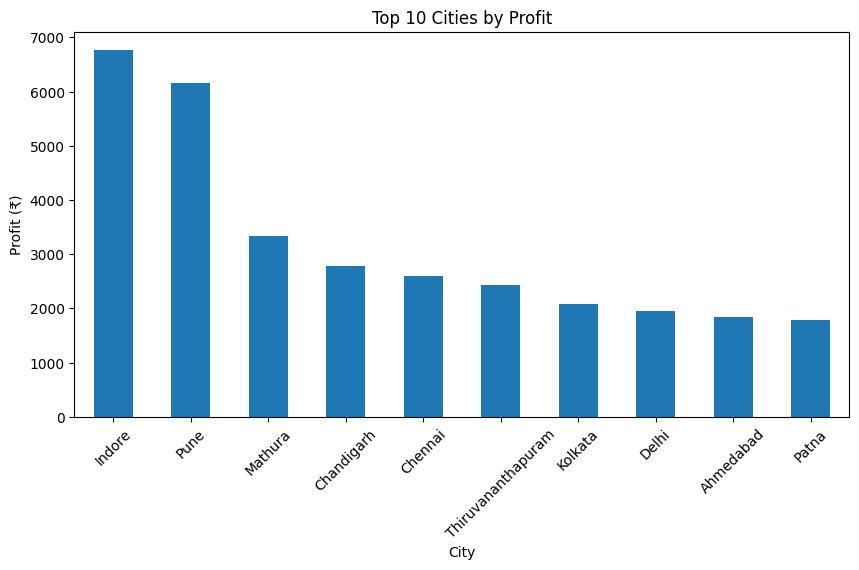

In [36]:
city_profit = city_analysis.sort_values(
    "Profit", ascending=False
).head(10)

city_profit["Profit"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Cities by Profit")
plt.xlabel("City")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=45)
plt.show()

## 🏷️ Sub-Category Analysis

In [27]:
subcategory_analysis = df.groupby("Sub-Category").agg(
    Sales=("Amount", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

subcategory_analysis = subcategory_analysis.sort_values(
    "Sales",
    ascending=False
)

subcategory_analysis

,Sales,Profit,Quantity
Sub-Category,,,
Printers,59252,8606,291
Saree,59094,4057,795
Bookcases,56861,6516,297
Phones,46119,1847,304
Electronic Games,39168,-644,297
Chairs,34222,1627,277
Trousers,30039,2847,135
Tables,22614,3139,61
Accessories,21728,3353,262


In [28]:
subcategory_analysis.head(10)

,Sales,Profit,Quantity
Sub-Category,,,
Printers,59252,8606,291
Saree,59094,4057,795
Bookcases,56861,6516,297
Phones,46119,1847,304
Electronic Games,39168,-644,297
Chairs,34222,1627,277
Trousers,30039,2847,135
Tables,22614,3139,61
Accessories,21728,3353,262


In [29]:
subcategory_analysis.sort_values(
    "Profit",
    ascending=False
).head(10)

,Sales,Profit,Quantity
Sub-Category,,,
Printers,59252,8606,291
Bookcases,56861,6516,297
Saree,59094,4057,795
Accessories,21728,3353,262
Tables,22614,3139,61
Trousers,30039,2847,135
Stole,18546,2431,671
Phones,46119,1847,304
Hankerchief,14294,1823,741


## 💳 Payment Mode Analysis

In [30]:
payment_analysis = df.groupby("PaymentMode").agg(
    Sales=("Amount", "sum"),
    Profit=("Profit", "sum"),
    Transactions=("Order ID", "count")
)

payment_analysis.sort_values("Sales", ascending=False)


,Sales,Profit,Transactions
PaymentMode,,,
COD,155181,12547,684
Credit Card,86932,12612,163
EMI,77881,4824,120
UPI,68641,3286,331
Debit Card,49136,3694,202


In [31]:
payment_count = df["PaymentMode"].value_counts()

payment_count

,count
PaymentMode,
COD,684
UPI,331
Debit Card,202
Credit Card,163
EMI,120


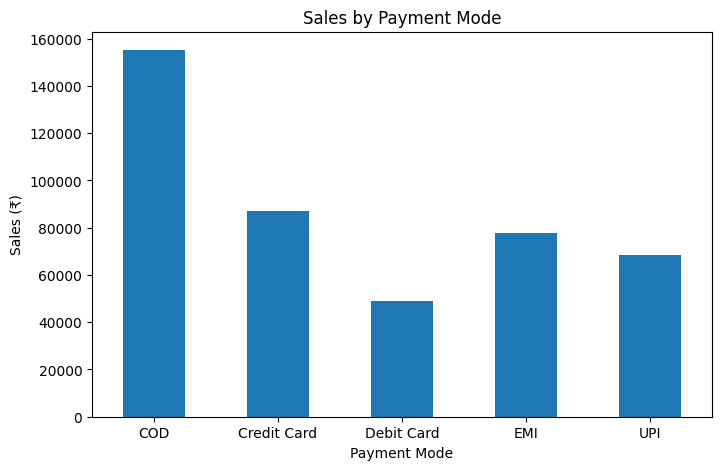

In [37]:
payment_analysis["Sales"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)
plt.show()

## 📊 Visualizations

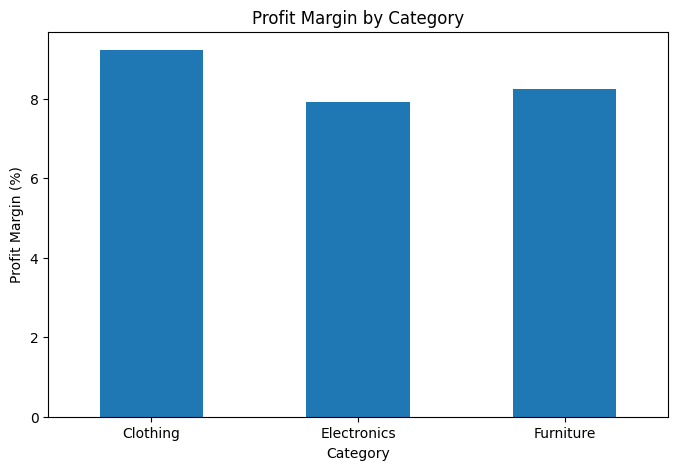

In [38]:
category_analysis["Profit Margin (%)"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

In [44]:
total_sales = df["Amount"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()

print("E-Commerce Sales Analysis :\n")
print(f"Total Sales: ₹{total_sales:,.0f}")
print(f"Total Profit: ₹{total_profit:,.0f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")

E-Commerce Sales Analysis :

Total Sales: ₹437,771
Total Profit: ₹36,963
Total Quantity Sold: 5,615
Total Orders: 500


# Key Business Insights

- Total sales were ₹4,37,771 and total profit was ₹36,963.
- Electronics generated the highest sales among the categories.
- Clothing recorded the highest profit margin among the categories.
- Indore recorded the highest sales among the cities analyzed.
- Indore also recorded the highest total profit among the cities shown.
- Mumbai generated high sales but comparatively low total profit.
- Electronic Games recorded negative aggregate profit despite generating substantial sales.
- COD recorded the highest sales among the payment modes.